# Reference-qualified and optimized meshes

This study compares meshes against a numerical, spatially and temporally qualified reference. The native CFL time step is retained for every trial; exact geometry is unchanged and each incidence is a separately rotated object case. Solver angles are stored in the solver frame, so object-frame custom curves use `+ incidence_deg` when converting them back.

In [1]:
%load_ext autoreload
%autoreload 2
%matplotlib inline
from pathlib import Path
import json
import numpy as np
import matplotlib.pyplot as plt
import fdtdmesh as fd
from fdtdmesh.benchmarks import (
    SHAPES, make_simulation, ReferenceSettings, qualify_reference,
    optimize_mesh, Optimization,
)

RUN_CASE = True
SELECTED_SHAPE = 'circle'
INCIDENCE_DEG = 0.0
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
STUDY_ROOT = PROJECT_ROOT / 'artifacts/notebooks/mesh_study'
REFERENCE_DIR = STUDY_ROOT / f'{SELECTED_SHAPE}_{INCIDENCE_DEG:g}' / 'reference'
OPTIMIZATION_DIR = STUDY_ROOT / f'{SELECTED_SHAPE}_{INCIDENCE_DEG:g}' / 'optimization'
REF_SETTINGS = ReferenceSettings(ppw=(48, 72, 108, 164), rtol=.002, worst_rtol=.005, max_seconds=900)

## Procedural shape catalog

All thumbnails use `make_simulation` and `Simulation.plot_geometry` before meshing. The view is zoomed to ±1 wavelength around the domain centre so small features remain visible.

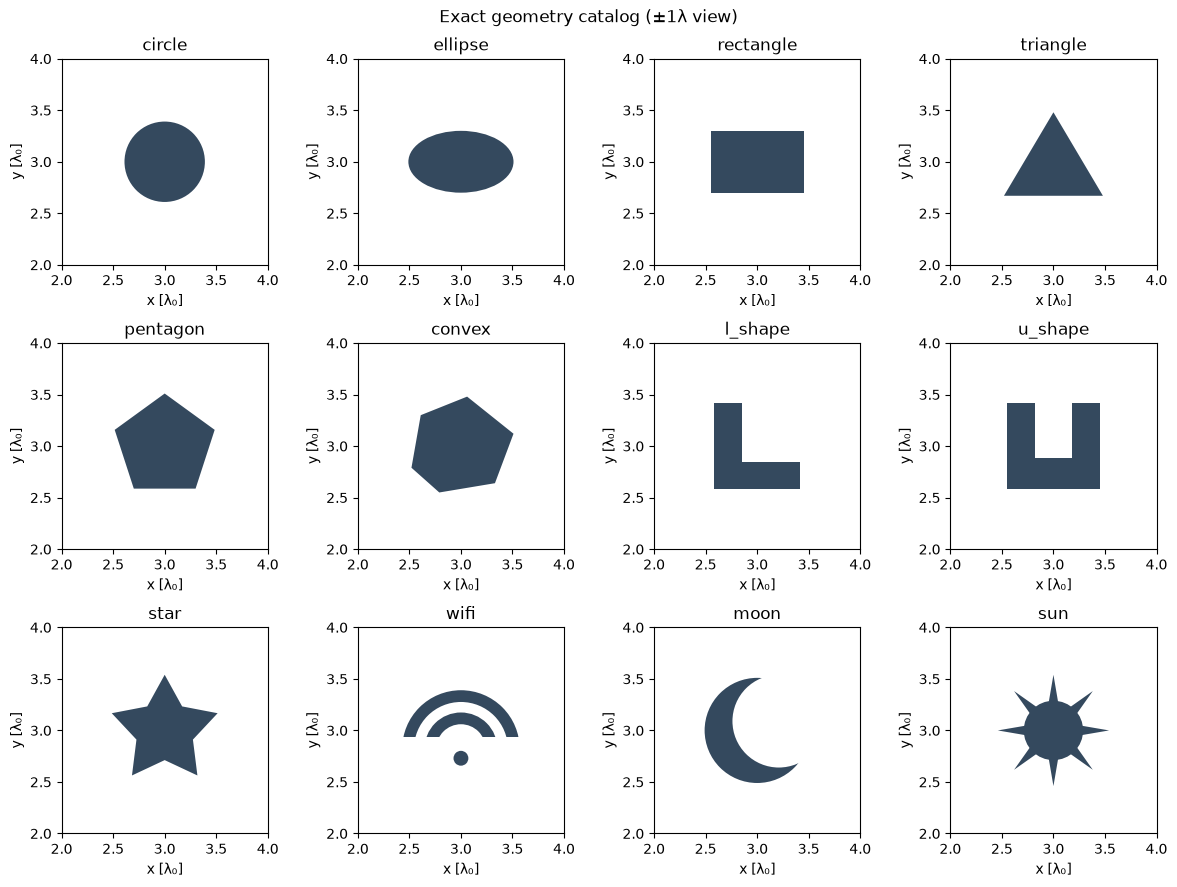

In [2]:
fig, axes = plt.subplots(3, 4, figsize=(12, 9))
for ax, shape in zip(axes.flat, SHAPES):
    thumb = make_simulation(shape=shape, incidence_deg=0)
    thumb.plot_geometry(mesh=False, units='wavelength', ax=ax)
    lam = thumb.wavelength
    cx, cy = np.asarray(thumb.size) / 2 / lam
    ax.set_xlim(cx - 1, cx + 1); ax.set_ylim(cy - 1, cy + 1)
    ax.set_title(shape); ax.get_legend().remove()
for ax in axes.flat[len(SHAPES):]: ax.axis('off')
fig.suptitle('Exact geometry catalog (±1λ view)')
fig.tight_layout()
plt.show()

## One reference and one optimization case

Reference qualification checks real spatial and temporal differences, PML sensitivity, and contour sensitivity. An unqualified reference is displayed and optimization is skipped; no result is presented as qualified by assumption.

Reference: qualified qualified= True


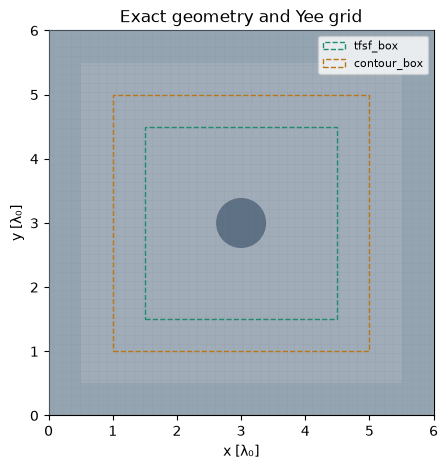

Optimization: evaluation_limit best_error= 0.015716091444379007


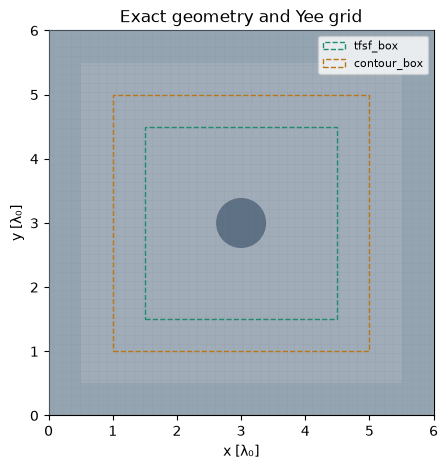

In [3]:
def _progress(item):
    status = item.get('status', 'running')
    level = item.get('ppw', item.get('number', ''))
    print(f'{status:>22}  {level}  error={item.get("error", item.get("best_error", ""))}')

sim = make_simulation(shape=SELECTED_SHAPE, incidence_deg=INCIDENCE_DEG)
reference = None
optimization = None
if RUN_CASE:
    reference = qualify_reference(sim, directory=REFERENCE_DIR, settings=REF_SETTINGS, progress=_progress)
    print('Reference:', reference.report.get('status'), 'qualified=', reference.qualified)
    if reference.result is not None:
        display(reference.result.plot_geometry(mesh=True, units='wavelength'))
    if reference.qualified:
        optimization = optimize_mesh(
            sim, reference, cells=(192, 192), strategy='differential_evolution',
            directory=OPTIMIZATION_DIR, max_evaluations=60, max_seconds=600,
            controls=6, population=12, seed=0, progress=_progress,
        )
        print('Optimization:', optimization.report.get('status'),
              'best_error=', optimization.report.get('best_error'))
    else:
        print('Skipping optimization because the numerical reference is not qualified.')

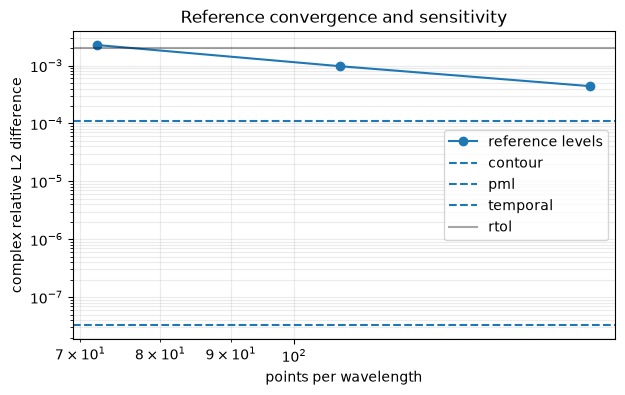

{'case': '5f8e35a33cb6c398451341d3872f36809084223ff07e18ee4869a908d13ab4b0',
 'checks': {'contour': {'cached': False,
   'error': 0.00011119807626462614,
   'passed': True,
   'per_frequency': [7.992765346725518e-05,
    8.235681763150022e-05,
    8.497486897509375e-05,
    8.77770820363242e-05,
    9.074349507938873e-05,
    9.384091311214609e-05,
    9.70265262886421e-05,
    0.00010025269595319009,
    0.000103472386595256,
    0.00010664473287996021,
    0.00010974027912613943,
    0.0001127454722222783,
    0.00011566600618707628,
    0.00011852861042883682,
    0.00012138087044254245,
    0.00012428871447126564,
    0.00012733134741175565,
    0.00013059370765151383,
    0.0001341569618222297,
    0.00013808805694347166,
    0.0001424297571673592],
   'width_error': 0.00011664962076429888,
   'worst_frequency': 0.0001424297571673592},
  'pml': {'cached': False,
   'error': 3.293150483141797e-08,
   'passed': True,
   'per_frequency': [4.9097866614261707e-08,
    4.729918066282617

In [4]:
if reference is not None:
    levels = [x for x in reference.report.get('levels', []) if x.get('difference')]
    fig, ax = plt.subplots(figsize=(7, 4))
    if levels:
        ax.loglog([x['ppw'] for x in levels], [x['difference']['error'] for x in levels], 'o-', label='reference levels')
    checks = reference.report.get('checks', {})
    for label, value in checks.items():
        if 'error' in value: ax.axhline(value['error'], ls='--', label=label)
    ax.axhline(REF_SETTINGS.rtol, color='k', alpha=.35, label='rtol')
    ax.set(xlabel='points per wavelength', ylabel='complex relative L2 difference', title='Reference convergence and sensitivity')
    ax.legend(); ax.grid(True, which='both', alpha=.25)
    plt.show()
    display(reference.report)

available baseline / optimized trials
label              error          gpu_ms       dt             status
uniform            0.01596972106545259 137.30812072753906 9.436639897710365e-12 feasible
deterministic      0.10801333858783212 478.23565673828125 4.557447876849057e-12 feasible
best               0.015716091444379007 192.36758422851562 6.639415846579954e-12 evaluation_limit


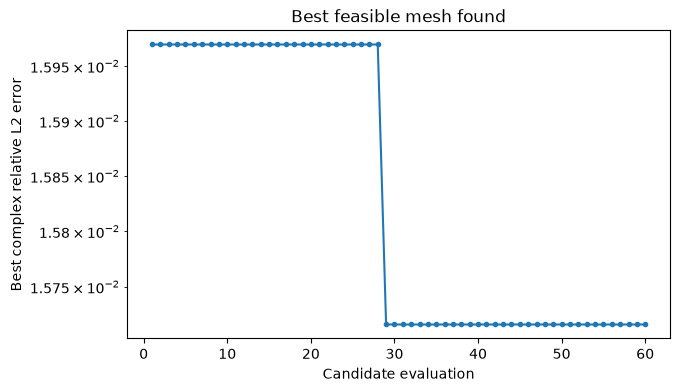

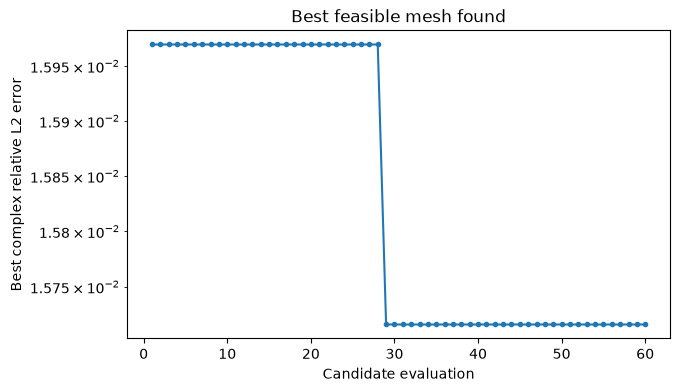

In [5]:
def _result_for_trial(opt, trial):
    return fd.Result.load(opt.directory / trial['result_file'])

if optimization is not None:
    baselines = {t['kind']: t for t in optimization.report['trials'] if t.get('kind') in ('uniform', 'deterministic')}
    rows = []
    for label, trial in baselines.items():
        if trial.get('result_file'):
            result = _result_for_trial(optimization, trial)
            rows.append((label, trial.get('error'), trial.get('gpu_ms'), result.diagnostics.get('dt'), trial.get('status')))
    rows.append(('best', optimization.report.get('best_error'),
                 optimization.best.diagnostics.get('gpu_ms') if optimization.best else None,
                 optimization.best.diagnostics.get('dt') if optimization.best else None,
                 optimization.report.get('status')))
    print('available baseline / optimized trials')
    print('label              error          gpu_ms       dt             status')
    for row in rows: print(f'{row[0]:<18} {str(row[1]):<14} {str(row[2]):<12} {str(row[3]):<14} {row[4]}')
    display(optimization.plot_history())

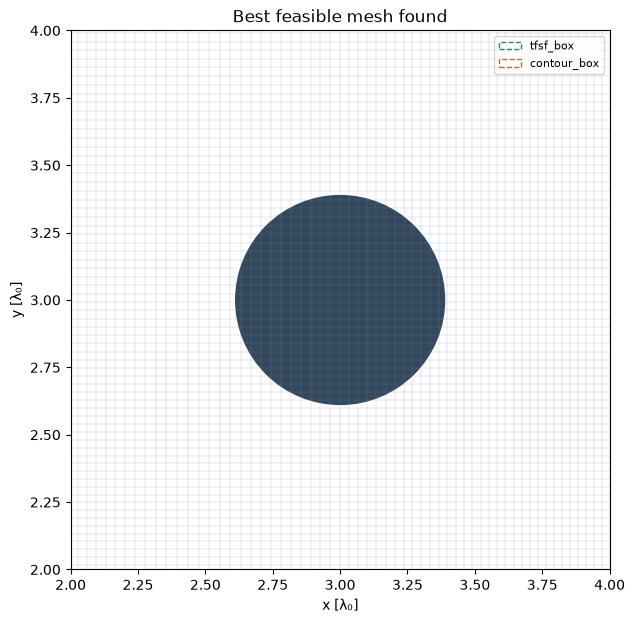

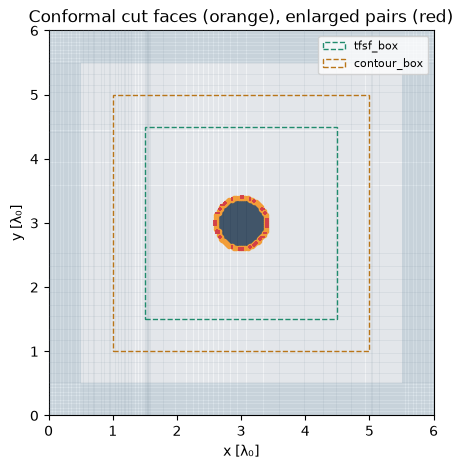

baseline errors: [('uniform', 0.01596972106545259), ('deterministic', 0.10801333858783212)]


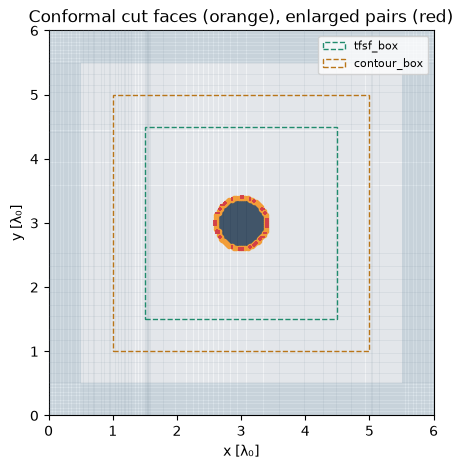

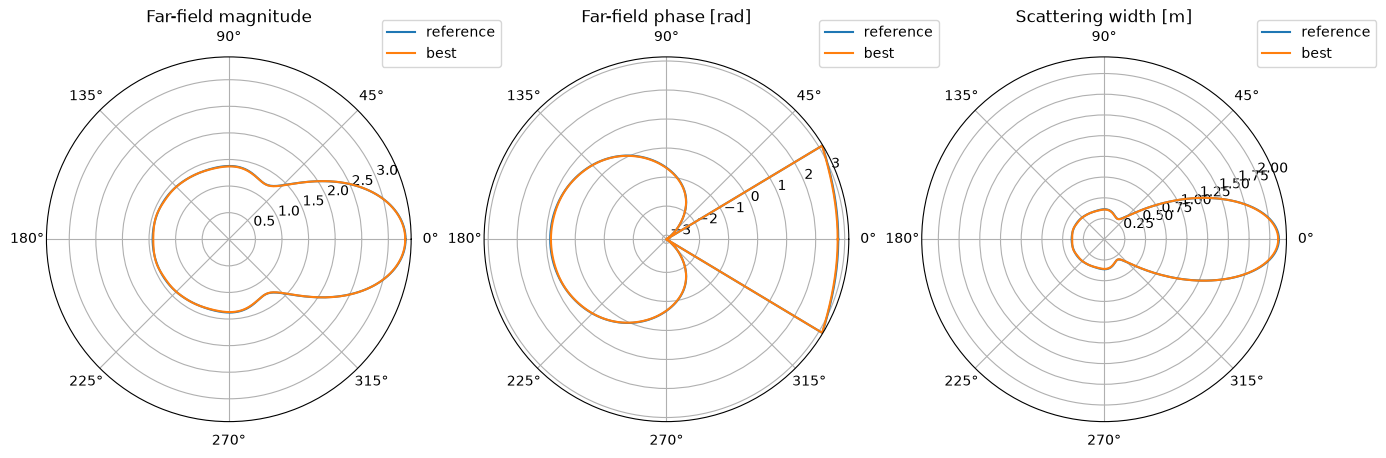

Winner tighter-stop validation: {'error': 0.015716091444379007, 'worst_frequency': 0.02083825616200266, 'per_frequency': [0.008482560130435279, 0.00906872825576554, 0.009816499506613962, 0.010664950732666375, 0.011556895715323328, 0.012444792942051088, 0.013292578161437932, 0.014075727639799673, 0.01478072519771596, 0.015404291739031828, 0.015952348346833522, 0.01643855043043204, 0.016882235168223327, 0.017305727275028365, 0.01773113472487484, 0.01817699884196803, 0.018655354804187195, 0.019169796070719152, 0.019714956917722303, 0.020277487812500702, 0.02083825616200266], 'width_error': 0.005774336200396383, 'change': {'error': 0.0, 'worst_frequency': 0.0, 'per_frequency': [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0], 'width_error': 0.0}, 'cached': True, 'result_file': 'validation\\4eccee967a0d37c0bb801feeeb575bf2b6fd0ae5fc481240fc645ead71c60ef7.h5', 'passed': True}
Absolute error reduction: 0.0002536; observed reference diff

In [6]:
if optimization is not None and optimization.best is not None:
    fig, ax = plt.subplots(figsize=(7, 7))
    optimization.best.plot_geometry(mesh=True, units='wavelength', ax=ax)
    cx, cy = np.asarray(sim.size) / (2 * sim.wavelength)
    ax.set(xlim=(cx-1, cx+1), ylim=(cy-1, cy+1), title='Best feasible mesh found')
    plt.show()
    best_sim = make_simulation(shape=SELECTED_SHAPE, incidence_deg=INCIDENCE_DEG)
    best_sim.apply_mesh(optimization.best.mesh)
    display(best_sim.plot_discretization(units='wavelength'))
    pairs = [(t['kind'], t.get('error')) for t in optimization.report['trials'] if t.get('kind') in ('uniform', 'deterministic')]
    print('baseline errors:', pairs)

    # Compare in the original object frame; all angle-dependent plots are polar.
    ref_result = reference.result
    index = len(ref_result.frequencies) // 2
    theta = ref_result.angles + np.deg2rad(INCIDENCE_DEG)
    order = np.argsort(np.mod(theta, 2*np.pi))
    theta = np.mod(theta[order], 2*np.pi)
    fig, axes = plt.subplots(1, 3, figsize=(16, 5), subplot_kw={'projection': 'polar'})
    for label, result in [('reference', ref_result), ('best', optimization.best)]:
        values = (abs(result.far_field[index]), np.angle(result.far_field[index]), result.width[index])
        for ax, value in zip(axes, values):
            ax.plot(np.r_[theta, theta[0]+2*np.pi], np.r_[value[order], value[order][0]], label=label)
    axes[1].set_ylim(-np.pi, np.pi)
    axes[1].set_rorigin(-np.pi)  # Signed phase is a radial level, not an angle rotation.
    for ax, title in zip(axes, ['Far-field magnitude', 'Far-field phase [rad]', 'Scattering width [m]']):
        ax.set_title(title)
        ax.legend(loc='upper left', bbox_to_anchor=(.9, 1.12))
    plt.show()
    print('Winner tighter-stop validation:', optimization.report.get('validation'))
    uniform = next((t.get('error') for t in optimization.report['trials'] if t['kind']=='uniform'), None)
    observed = reference.report.get('observed_reference_difference')
    if uniform is not None and observed is not None:
        gain = uniform - optimization.report['best_error']
        print(f'Absolute error reduction: {gain:.4g}; observed reference difference: {observed:.4g}')
        if gain <= observed:
            print('The improvement is not resolved beyond the observed reference difference.')


## Optional sweep

The sweep is disabled by default. It preserves per-incidence reference and optimization archives, including DE population/RNG checkpoints and Powell warm restarts. Rows retain unqualified cases for later inspection; they do not claim every shape is feasible or globally optimal.

In [7]:
RUN_SWEEP = False
if RUN_SWEEP:
    from fdtdmesh.benchmarks import run_sweep, plot_gallery
    sweep_rows = run_sweep(
        SHAPES, (0, 30, 60, 90), directory=STUDY_ROOT / 'sweep', cells=(192, 192),
        reference_settings=REF_SETTINGS, strategy='differential_evolution',
        max_evaluations=60, max_seconds=600, progress=_progress,
    )
    display(sweep_rows)

study_manifest = STUDY_ROOT / 'sweep' / 'study.json'
if study_manifest.exists():
    from fdtdmesh.benchmarks import plot_gallery
    display(plot_gallery(STUDY_ROOT / 'sweep', shapes=SHAPES, incidences=(0, 30, 60, 90)))